In [1]:
import os
import warnings
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import joblib

In [42]:
MODEL_DIR = "models"
OUTPUT_DIR = "outputs"
FIGURE_DIR = "figures"
PREDICTIONS_PARQUET = "predictions_with_timestamps.parquet"
INPUT_DATA = "train_unlabelled.parquet"

# Temporal Scope
ANALYSIS_START = datetime(2024, 5, 1)
ANALYSIS_END = datetime(2024, 11, 30, 23, 59, 59)

# Key Events
EVENTS = {
    "Trump Assassination Attempt": datetime(2024, 7, 13),
    "Biden Withdrawal": datetime(2024, 7, 21),
    "Harris Nomination": datetime(2024, 8, 6),
    "Election Day": datetime(2024, 11, 5)
}

# Campaign Phases
PHASES = {
    "Biden Campaign": (datetime(2024, 5, 1), datetime(2024, 7, 21)),
    "Harris Campaign": (datetime(2024, 7, 22), datetime(2024, 11, 5)),
    "Post-Election": (datetime(2024, 11, 6), datetime(2024, 11, 30))
}


In [3]:
def assign_campaign_phase(ts):
    if pd.isna(ts): return "Unknown"
    for phase, (start, end) in PHASES.items():
        if start <= ts <= end: return phase
    return "Outside Scope"


In [10]:
df = pd.read_parquet(PREDICTIONS_PARQUET)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df[(df['timestamp'] >= ANALYSIS_START) & (df['timestamp'] <= ANALYSIS_END)]
df.head(5)

,id,clean_text,text,timestamp,party,sentiment
0,1844361929781113331,many failure bidens administration directly tr...,@a_newsman Many failures of Bidens administrat...,2024-10-10,democrat,negative
1,1844361929550332320,lie biden told american misinformation set exa...,@atensnut The lies Biden told Americans about ...,2024-10-10,democrat,negative
2,1844361928925384711,someone talented fundraising team,@TheDemocrats here’s someone very talented for...,2024-10-10,democrat,positive
3,1844361928585654516,chipper usd card working expressionless face,@LifeOfNapaul Chipper USD card isn’t working 😑,2024-10-10,democrat,negative
4,1844361927495123076,yes n't done live interview real journalist si...,@MTGrepp Yes. She hasn't done a live interview...,2024-10-10,democrat,positive


In [49]:
def compute_daily_sentiment(df):
    """Compute daily positive sentiment ratio by party."""
    df_clean = df.dropna(subset=['party', 'sentiment', 'timestamp']).copy()
    df_clean['date'] = pd.to_datetime(df_clean['timestamp']).dt.date
    
    daily_sentiment = []
    for party in ['democrat', 'republican']:
        party_df = df_clean[df_clean['party'] == party]
        daily = party_df.groupby('date').agg({
            'sentiment': lambda x: (x == 'positive').sum() / len(x) if len(x) > 0 else np.nan
        }).reset_index()
        daily.columns = ['date', 'positive_ratio']
        daily['party'] = party
        daily['tweet_count'] = party_df.groupby('date').size().values
        daily_sentiment.append(daily)
    
    return pd.concat(daily_sentiment, ignore_index=True)


def compute_rolling_average(daily_df, window=7):
    """Compute rolling average sentiment with standard deviation."""
    results = []
    
    for party in ['democrat', 'republican']:
        party_df = daily_df[daily_df['party'] == party].copy()
        party_df = party_df.sort_values('date')
        
        # Rolling mean
        party_df['rolling_mean'] = party_df['positive_ratio'].rolling(
            window=window, min_periods=1, center=False
        ).mean()
        
        # Rolling std for confidence bands
        party_df['rolling_std'] = party_df['positive_ratio'].rolling(
            window=window, min_periods=1, center=False
        ).std()
        
        results.append(party_df)
    
    return pd.concat(results, ignore_index=True)


def analyze_campaign_phases(df):
    """Compare sentiment across campaign phases with statistical testing."""
    df_clean = df.dropna(subset=['party', 'sentiment', 'timestamp']).copy()
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    df_clean['phase'] = df_clean['timestamp'].apply(assign_campaign_phase)
    
    # Filter to main campaign phases
    main_phases = ['Biden Campaign', 'Harris Campaign', 'Post-Election']
    df_analysis = df_clean[df_clean['phase'].isin(main_phases)]
    
    results = []
    for party in ['democrat', 'republican']:
        party_df = df_analysis[df_analysis['party'] == party]
        
        for phase in main_phases:
            phase_df = party_df[party_df['phase'] == phase]
            if len(phase_df) == 0:
                continue
            
            pos_count = (phase_df['sentiment'] == 'positive').sum()
            total = len(phase_df)
            pos_ratio = pos_count / total
            
            # Wilson score confidence interval (95%)
            z = 1.96
            denominator = 1 + z**2/total
            centre = (pos_ratio + z**2/(2*total)) / denominator
            margin = z * np.sqrt(pos_ratio*(1-pos_ratio)/total + z**2/(4*total**2)) / denominator
            
            results.append({
                'party': party,
                'phase': phase,
                'total_tweets': total,
                'positive_ratio': pos_ratio,
                'ci_lower': centre - margin,
                'ci_upper': centre + margin
            })
    
    phase_df = pd.DataFrame(results)
    
    # Statistical test: Compare Harris vs Biden for each party
    print("Statistical test: Biden vs Harris Campaign")
    for party in ['democrat', 'republican']:
        biden_sent = df_analysis[(df_analysis['party'] == party) & 
                                 (df_analysis['phase'] == 'Biden Campaign')]['sentiment']
        harris_sent = df_analysis[(df_analysis['party'] == party) & 
                                  (df_analysis['phase'] == 'Harris Campaign')]['sentiment']
        
        if len(biden_sent) > 0 and len(harris_sent) > 0:
            biden_pos = (biden_sent == 'positive').sum() / len(biden_sent)
            harris_pos = (harris_sent == 'positive').sum() / len(harris_sent)
            
            # Chi-square test
            contingency = pd.crosstab(
                pd.Series(['Biden']*len(biden_sent) + ['Harris']*len(harris_sent)),
                pd.Series(list(biden_sent) + list(harris_sent))
            )
            chi2, p_value, _, _ = stats.chi2_contingency(contingency)
            
            print(f"\n{party}:")
            print(f"  Biden Campaign:  {biden_pos:.4f} positive (n={len(biden_sent):,})")
            print(f"  Harris Campaign: {harris_pos:.4f} positive (n={len(harris_sent):,})")
            print(f"  Change: {(harris_pos - biden_pos):+.4f} ({((harris_pos/biden_pos - 1)*100):+.1f}%)")
            print(f"  χ² = {chi2:.2f}, p = {p_value:.6f}")
            if p_value < 0.001:
                print(f"  Result: Highly significant ***")
            elif p_value < 0.01:
                print(f"  Result: Significant **")
            elif p_value < 0.05:
                print(f"  Result: Significant *")
            else:
                print(f"  Result: Not significant")
    
    return phase_df


def analyze_event_impact(df, window_days=7):
    """Statistically evaluates if an event shifted sentiment."""
    df_clean = df.dropna(subset=['party', 'sentiment', 'timestamp']).copy()
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    
    results = []
    
    for event_name, event_date in EVENTS.items():
        # Remove newlines from event name for table
        event_clean = event_name.replace('\n', ' ')
        
        baseline_start = event_date - timedelta(days=window_days*2)
        baseline_end = event_date - timedelta(days=window_days)
        post_start = event_date
        post_end = event_date + timedelta(days=window_days)
        
        for party in ['democrat', 'republican']:
            party_df = df_clean[df_clean['party'] == party]
            
            # Baseline sentiment
            baseline_df = party_df[(party_df['timestamp'] >= baseline_start) & 
                                   (party_df['timestamp'] < baseline_end)]
            # Post-event sentiment
            post_df = party_df[(party_df['timestamp'] >= post_start) & 
                              (party_df['timestamp'] <= post_end)]
            
            if len(baseline_df) > 15 and len(post_df) > 15:
                baseline_pos = (baseline_df['sentiment'] == 'positive').mean()
                post_pos = (post_df['sentiment'] == 'positive').mean()
                
                # Statistical test
                contingency = pd.crosstab(
                    pd.Series(['baseline']*len(baseline_df) + ['post']*len(post_df)),
                    pd.Series(list(baseline_df['sentiment']) + list(post_df['sentiment']))
                )
                chi2, p_value, _, _ = stats.chi2_contingency(contingency)
                
                results.append({
                    'event': event_clean,
                    'party': party,
                    'baseline_positive': baseline_pos,
                    'post_event_positive': post_pos,
                    'change': post_pos - baseline_pos,
                    'change_pct': ((post_pos / baseline_pos - 1) * 100) if baseline_pos > 0 else 0,
                    'p_value': p_value,
                    'significant': p_value < 0.05,
                    'baseline_n': len(baseline_df),
                    'post_n': len(post_df)
                })
    
    return pd.DataFrame(results)


def plot_rolling_sentiment(rolling_df, save_path=None):
    """Plot 7-day rolling average sentiment with events marked."""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors = {'democrat': '#0015BC', 'republican': '#E81B23'}
    
    for party in ['democrat', 'republican']:
        party_df = rolling_df[rolling_df['party'] == party].copy()
        party_df['date'] = pd.to_datetime(party_df['date'])
        party_df = party_df.sort_values('date')
        
        # Main line
        ax.plot(party_df['date'], party_df['rolling_mean'], 
                label=party.capitalize(), color=colors[party], linewidth=2.5, alpha=0.9)
        
        # Confidence band (±1 std)
        ax.fill_between(party_df['date'], 
                        party_df['rolling_mean'] - party_df['rolling_std'],
                        party_df['rolling_mean'] + party_df['rolling_std'],
                        color=colors[party], alpha=0.15)
    
    # Mark key events
    for event_name, event_date in EVENTS.items():
        ax.axvline(event_date, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(event_date, ax.get_ylim()[1]*0.96, event_name, 
                rotation=90, verticalalignment='top', fontsize=9, alpha=0.7)
    
    # Mark phase boundaries
    ax.axvline(PHASES["Biden Campaign"][1], color='black', linestyle=':', alpha=0.3, linewidth=1.5)
    ax.axvline(PHASES["Harris Campaign"][1], color='black', linestyle=':', alpha=0.3, linewidth=1.5)
    
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Positive Sentiment (7-Day Rolling Average)', fontsize=11)
    ax.set_title('Temporal Evolution of Partisan Sentiment During 2024 Election', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()
    

def plot_phase_comparison(phase_df, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    phases = ['Biden Campaign', 'Harris Campaign', 'Post-Election']
    x = np.arange(len(phases))
    width = 0.35
    colors = {'democrat': '#0015BC', 'republican': '#E81B23'}
    
    for i, party in enumerate(['democrat', 'republican']):
        party_data = phase_df[phase_df['party'] == party]
        means = [party_data[party_data['phase'] == p]['positive_ratio'].values[0] if not party_data[party_data['phase'] == p].empty else 0 for p in phases]
        lows = [means[j] - party_data[party_data['phase'] == phases[j]]['ci_lower'].values[0] if not party_data[party_data['phase'] == phases[j]].empty else 0 for j in range(len(phases))]
        highs = [party_data[party_data['phase'] == phases[j]]['ci_upper'].values[0] - means[j] if not party_data[party_data['phase'] == phases[j]].empty else 0 for j in range(len(phases))]
        
        ax.bar(x + i*width, means, width, label=party.capitalize(), color=colors[party], alpha=0.8, yerr=[lows, highs], capsize=5)
    
    ax.set_xticks(x + width / 2)
    # Set rotation to 0 and ha to center
    ax.set_xticklabels(phases, rotation=0, ha='center') 
    ax.set_title('Partisan Sentiment Across Campaign Phases', fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=300)
    plt.show()

def plot_event_impact(event_df, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    events = event_df['event'].unique()
    events_formatted = [e.replace(' ', '\n', 1) if len(e) > 15 else e for e in events]
    
    x = np.arange(len(events))
    width = 0.35
    colors = {'democrat': '#0015BC', 'republican': '#E81B23'}
    
    for i, party in enumerate(['democrat', 'republican']):
        party_data = event_df[event_df['party'] == party]
        for j, event in enumerate(events):
            row = party_data[party_data['event'] == event]
            if not row.empty:
                ax.bar(x[j] + i*width, row['change'].values[0], width, 
                       color=colors[party], alpha=0.9 if row['significant'].values[0] else 0.3)
    
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(x + width / 2)
    # Set rotation to 0
    ax.set_xticklabels(events_formatted, rotation=0, ha='center', fontsize=9)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=300)
    plt.show()

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Filter to analysis period
df_filtered = df[(df['timestamp'] >= ANALYSIS_START) & 
                 (df['timestamp'] <= ANALYSIS_END)].copy()

print(f"\nAnalyzing {len(df_filtered):,} tweets from {ANALYSIS_START.date()} to {ANALYSIS_END.date()}")
df.head()


Analyzing 35,812,752 tweets from 2024-05-01 to 2024-11-30


,id,clean_text,text,timestamp,party,sentiment
0,1844361929781113331,many failure bidens administration directly tr...,@a_newsman Many failures of Bidens administrat...,2024-10-10,democrat,negative
1,1844361929550332320,lie biden told american misinformation set exa...,@atensnut The lies Biden told Americans about ...,2024-10-10,democrat,negative
2,1844361928925384711,someone talented fundraising team,@TheDemocrats here’s someone very talented for...,2024-10-10,democrat,positive
3,1844361928585654516,chipper usd card working expressionless face,@LifeOfNapaul Chipper USD card isn’t working 😑,2024-10-10,democrat,negative
4,1844361927495123076,yes n't done live interview real journalist si...,@MTGrepp Yes. She hasn't done a live interview...,2024-10-10,democrat,positive


In [13]:
daily_sentiment = compute_daily_sentiment(df_filtered)
daily_sentiment.to_csv(os.path.join(OUTPUT_DIR, "daily_sentiment.csv"), index=False)
print(f"Saved in {OUTPUT_DIR}/daily_sentiment.csv")


Saved in outputs/daily_sentiment.csv


In [14]:
rolling_sentiment = compute_rolling_average(daily_sentiment, window=7)
rolling_sentiment.to_csv(os.path.join(OUTPUT_DIR, "rolling_sentiment.csv"), index=False)
print(f"Saved in {OUTPUT_DIR}/rolling_sentiment.csv")


Saved in outputs/rolling_sentiment.csv


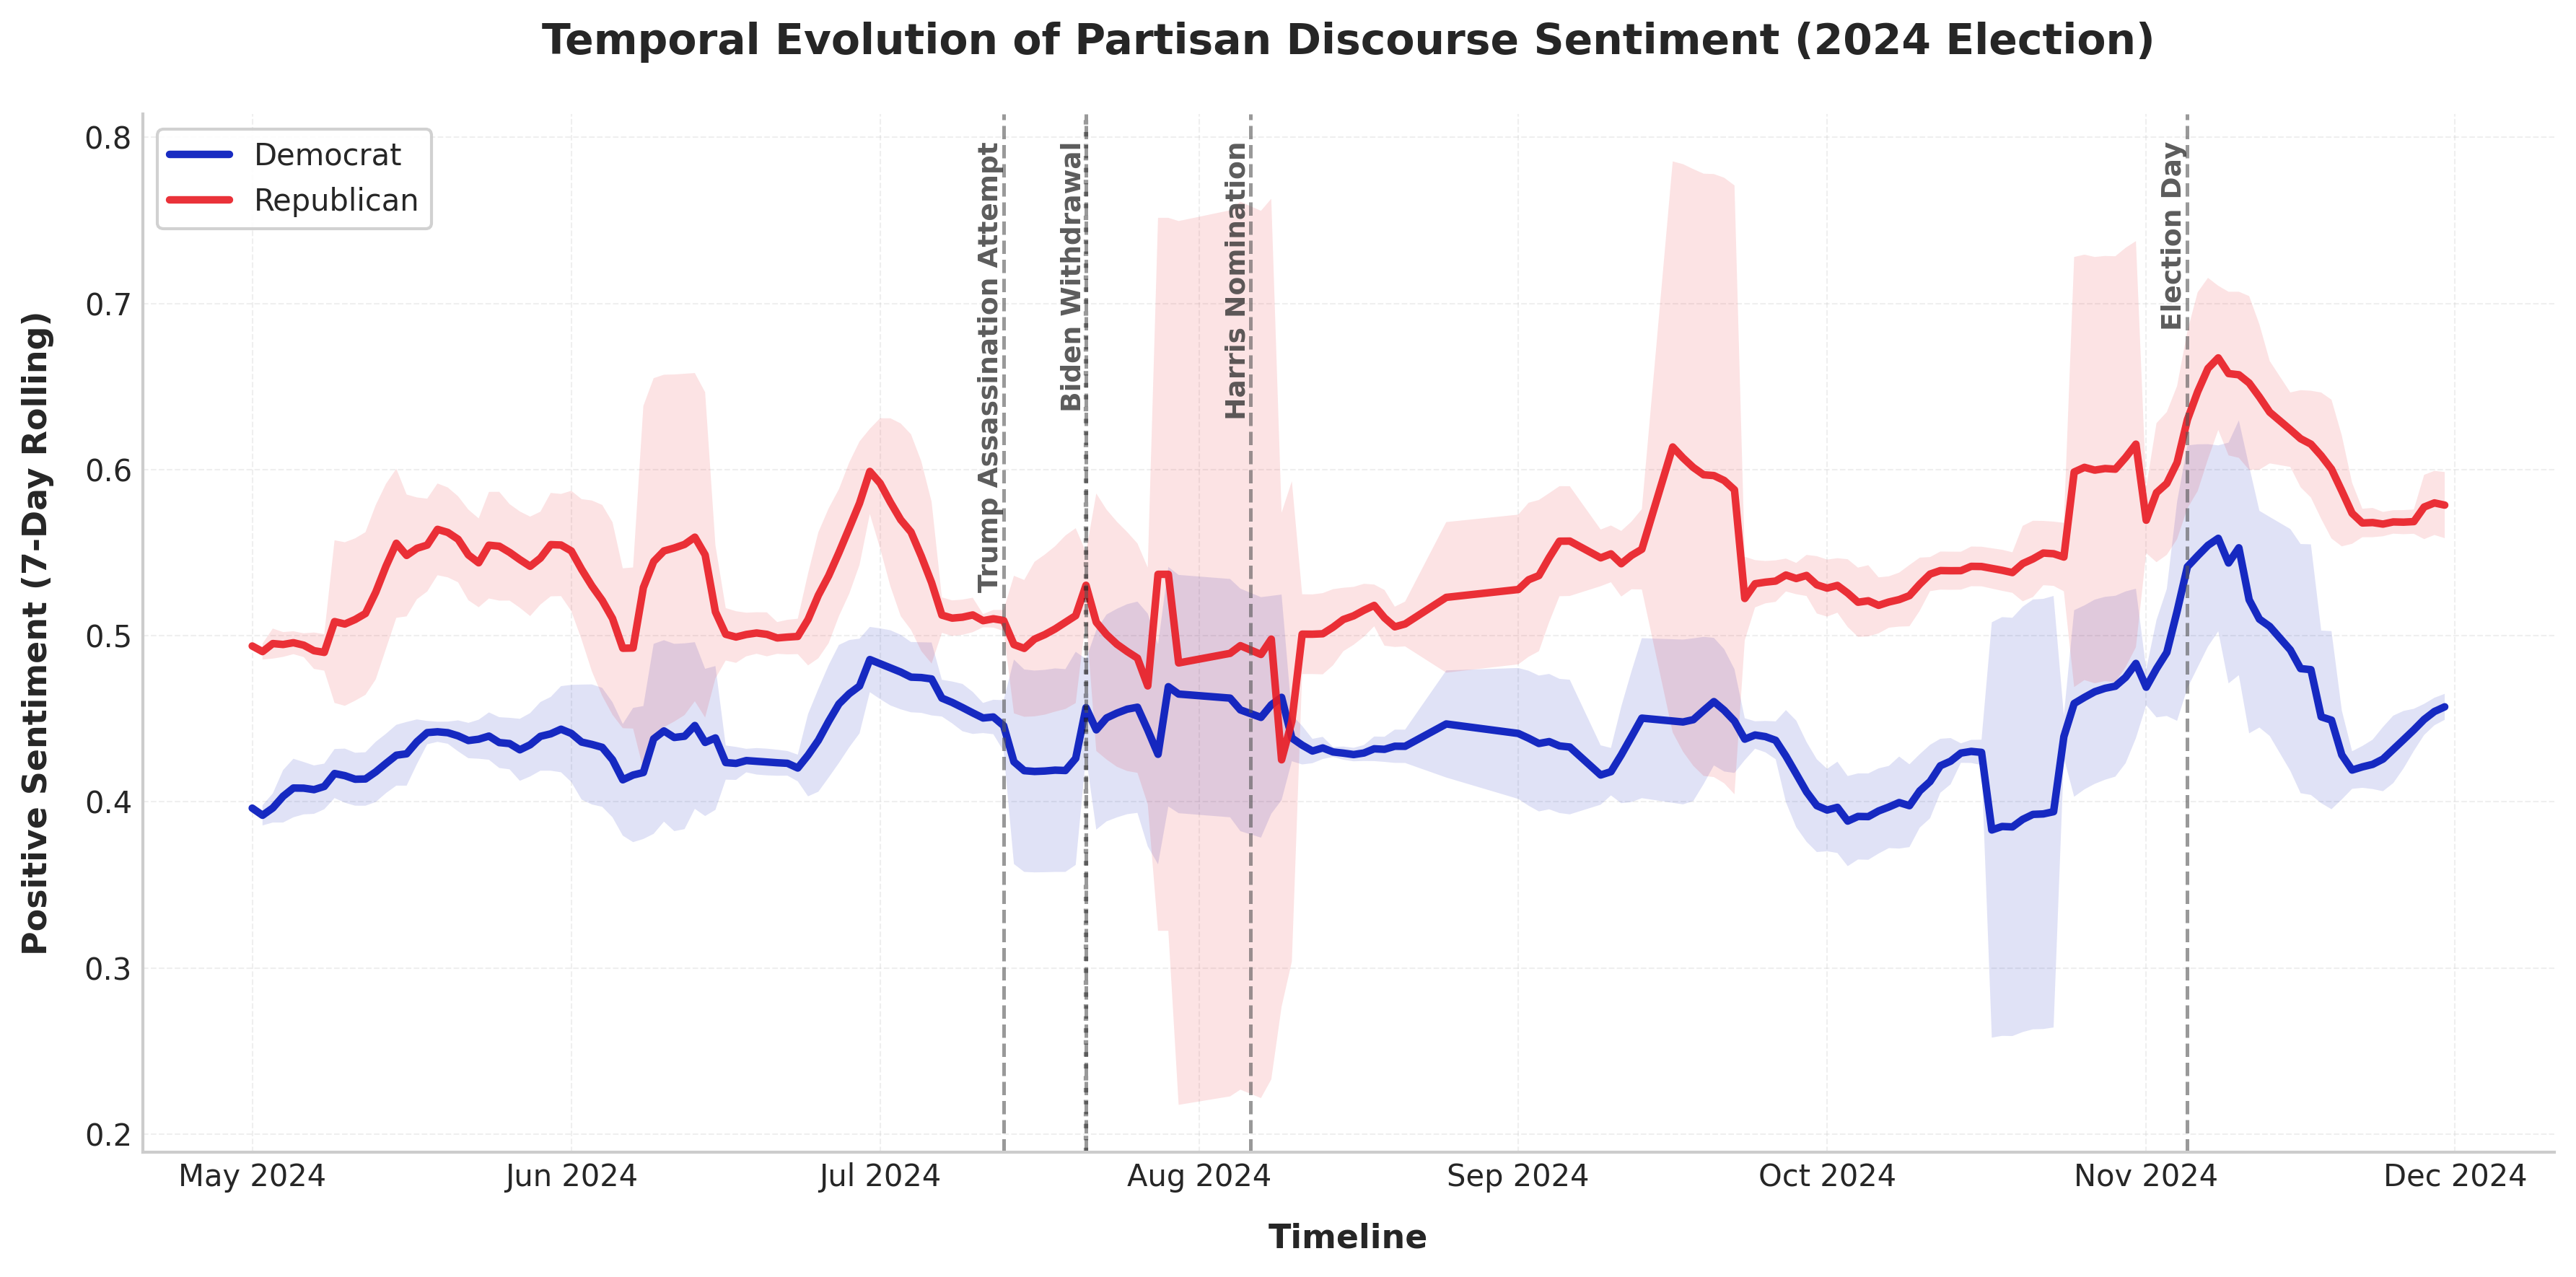

In [44]:
def plot_rolling_sentiment(rolling_df, save_path=None):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    
    colors = {'democrat': '#0015BC', 'republican': '#E81B23'}
    
    for party in ['democrat', 'republican']:
        party_df = rolling_df[rolling_df['party'] == party].copy()
        party_df['date'] = pd.to_datetime(party_df['date'])
        party_df = party_df.sort_values('date')
        
        ax.plot(party_df['date'], party_df['rolling_mean'], 
                label=party.capitalize(), color=colors[party], linewidth=2.5, alpha=0.9)
        
        ax.fill_between(party_df['date'], 
                        party_df['rolling_mean'] - party_df['rolling_std'],
                        party_df['rolling_mean'] + party_df['rolling_std'],
                        color=colors[party], alpha=0.12, edgecolor='none')
    
    # Grid and Ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=0)
    
    # Mark key events
    for event_name, event_date in EVENTS.items():
        ax.axvline(event_date, color='#555555', linestyle='--', alpha=0.6, linewidth=1.2)
        ax.text(event_date, ax.get_ylim()[1] * 0.98, event_name, 
                rotation=90, verticalalignment='top', horizontalalignment='right', 
                fontsize=9, alpha=0.8, fontweight='bold', color='#333333')
    
    # Mark phase boundaries
    ax.axvline(PHASES["Biden Campaign"][1], color='black', linestyle=':', alpha=0.4, linewidth=1.5)
    
    ax.set_xlabel('Timeline', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel('Positive Sentiment (7-Day Rolling)', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_title('Temporal Evolution of Partisan Discourse Sentiment (2024 Election)', 
                 fontsize=14, fontweight='bold', pad=20)
    
    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Final touches
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

rolling_res = compute_rolling_average(rolling_sentiment)

plot_rolling_sentiment(rolling_res, save_path=os.path.join(FIGURE_DIR, "rolling_sentiment.png"))


Statistical test: Biden vs Harris Campaign

democrat:
  Biden Campaign:  0.4336 positive (n=13,102,406)
  Harris Campaign: 0.4297 positive (n=10,052,877)
  Change: -0.0039 (-0.9%)
  χ² = 349.27, p = 0.000000
  Result: Highly significant ***

republican:
  Biden Campaign:  0.5066 positive (n=3,764,801)
  Harris Campaign: 0.5221 positive (n=4,219,004)
  Change: +0.0155 (+3.1%)
  χ² = 1924.44, p = 0.000000
  Result: Highly significant ***
Saved in outputs/phase_sentiment.csv


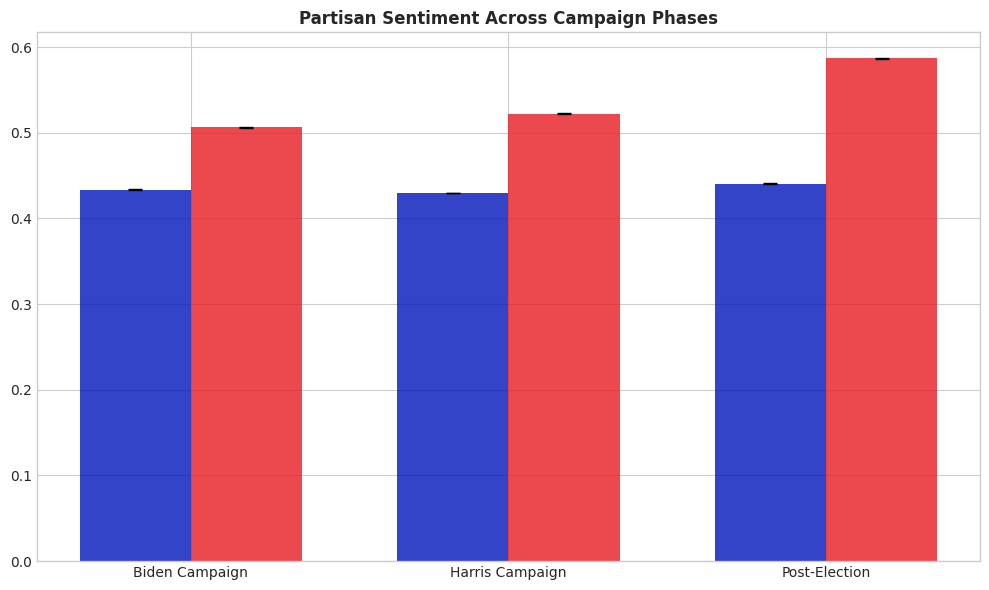

In [50]:
phase_sentiment = analyze_campaign_phases(df_filtered)
phase_sentiment.to_csv(os.path.join(OUTPUT_DIR, "phase_sentiment.csv"), index=False)
print(f"Saved in {OUTPUT_DIR}/phase_sentiment.csv")

plot_phase_comparison(
    phase_sentiment,
    save_path=os.path.join(FIGURE_DIR, "phase_comparison.png")
)


In [51]:
phase_sentiment

,party,phase,total_tweets,positive_ratio,ci_lower,ci_upper
0,democrat,Biden Campaign,13102406,0.433602,0.433334,0.433870
1,democrat,Harris Campaign,10052877,0.429720,0.429414,0.430026
2,democrat,Post-Election,3233731,0.440299,0.439758,0.440840
3,republican,Biden Campaign,3764801,0.506557,0.506052,0.507062
4,republican,Harris Campaign,4219004,0.522102,0.521625,0.522578
5,republican,Post-Election,1439933,0.587045,0.586241,0.587849


In [52]:
event_impact = analyze_event_impact(df_filtered, window_days=7)
event_impact.to_csv(os.path.join(OUTPUT_DIR, "event_impact.csv"), index=False)

event_impact

,event,party,baseline_positive,post_event_positive,change,change_pct,p_value,significant,baseline_n,post_n
0,Trump Assassination Attempt,democrat,0.467919,0.419411,-0.048508,-10.366721,0.000000e+00,True,567624,3653547
1,Trump Assassination Attempt,republican,0.516420,0.502061,-0.014358,-2.780316,6.061718e-42,True,262310,1503824
2,Biden Withdrawal,democrat,0.446304,0.490332,0.044028,9.865042,0.000000e+00,True,3104446,1277591
3,Biden Withdrawal,republican,0.508060,0.510533,0.002473,0.486779,1.633743e-02,True,580412,397753
4,Harris Nomination,democrat,0.477807,0.430833,-0.046974,-9.831200,0.000000e+00,True,628222,1300028
5,Harris Nomination,republican,0.502653,0.505332,0.002679,0.533030,1.828886e-02,True,281616,626426
6,Election Day,democrat,0.430845,0.477930,0.047085,10.928547,3.344266e-221,True,177370,311263
7,Election Day,republican,0.541349,0.671845,0.130496,24.105728,0.000000e+00,True,95698,177023


Trump Assassination Attempt    | democrat   | Change: -0.0485 (-10.4%) ***
Trump Assassination Attempt    | republican | Change: -0.0144 (-2.8%) ***
Biden Withdrawal               | democrat   | Change: +0.0440 (+9.9%) ***
Biden Withdrawal               | republican | Change: +0.0025 (+0.5%) ***
Harris Nomination              | democrat   | Change: -0.0470 (-9.8%) ***
Harris Nomination              | republican | Change: +0.0027 (+0.5%) ***
Election Day                   | democrat   | Change: +0.0471 (+10.9%) ***
Election Day                   | republican | Change: +0.1305 (+24.1%) ***


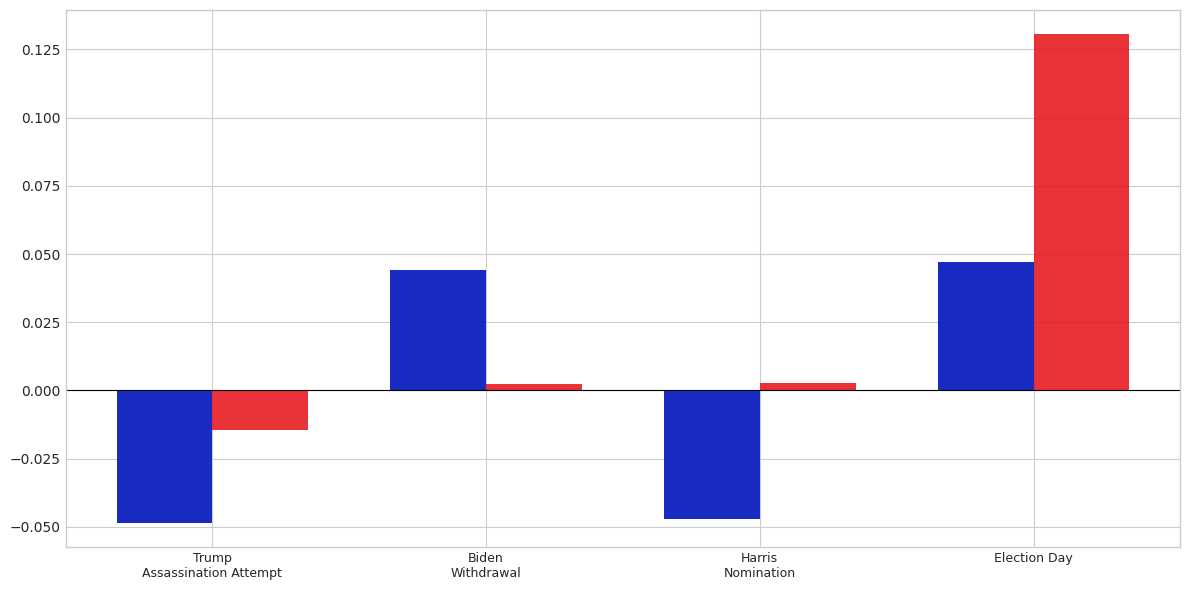

In [53]:
for _, row in event_impact.iterrows():
    sig_marker = "***" if row['significant'] else ""
    print(f"{row['event']:30s} | {row['party']:10s} | "
          f"Change: {row['change']:+.4f} ({row['change_pct']:+.1f}%) {sig_marker}")

plot_event_impact(
    event_impact,
    save_path=os.path.join(FIGURE_DIR, "event_impact.png")
)
